# Professional F1 Analysis And Machine Learning
This notebook extends the basic exploration in `F1_data_analysis.ipynb` and turns the dataset into a reusable analytics project.

We do three things:
1. Build a clean modeling dataset from the raw Formula 1 tables.
2. Run professional exploratory analysis on race outcomes and pit-stop behavior.
3. Train pipeline-ready machine learning models for finish-position regression and podium classification.


## Mathematical Framing
 Let each race-entry observation be a pair $(x_i, y_i)$ where:
- $x_i$ is the feature vector before the race starts.
- $y_i$ is either the finishing position or a podium indicator.
The supervised learning problem is:
           $$
            f: x_i \rightarrow y_i
            $$
We approximate the unknown function $f$ with models trained on historical races.
Main concepts used in this notebook:
 - **Feature engineering**: transform raw tables into predictive variables such as rolling average finish and prior season points
 - **Pipeline**: a composition $g(x) = m(h(x))$ where $h$ is preprocessing and $m$ is the estimator.
 - **Temporal validation**: train on past seasons, validate on a later season, test on the final unseen season.


In [7]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from f1_analysis.config import MODEL_DIR, PROCESSED_DATA_DIR, REPORT_DIR
from f1_analysis.dataset import build_modeling_dataset, build_pit_stop_dataset, load_core_tables
from f1_analysis.modeling import FEATURE_COLUMNS, train_and_select_models

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)


The first action imports the reusable project code instead of rewriting logic inline.
Result:
- The notebook stays readable.
- The same feature engineering code can later feed an API or batch pipeline.
- Model artifacts saved from this notebook are directly reusable with `joblib`.


In [8]:
tables = load_core_tables()
pit_stop_dataset = build_pit_stop_dataset(tables)
modeling_dataset = build_modeling_dataset(tables)

print("Pit-stop dataset shape:", pit_stop_dataset.shape)
print("Modeling dataset shape:", modeling_dataset.shape)
print("Modeling years:", modeling_dataset["year"].min(), "to", modeling_dataset["year"].max())
modeling_dataset[[
                "year",
                "raceId",
                "driver_name",
                "constructor_name",
                "grid",
                "qualifying_position",
                "positionOrder",
                "driver_avg_finish_last_5",
                "constructor_avg_finish_last_5",
            ]].head()


Pit-stop dataset shape: (6251, 16)
Modeling dataset shape: (4165, 65)
Modeling years: 2008 to 2017


,year,raceId,driver_name,constructor_name,grid,qualifying_position,positionOrder,driver_avg_finish_last_5,constructor_avg_finish_last_5
0,2008,18,Lewis Hamilton,McLaren,1,1.0,1,NaN,NaN
1,2008,18,Nick Heidfeld,BMW Sauber,5,5.0,2,NaN,NaN
2,2008,18,Nico Rosberg,Williams,7,7.0,3,NaN,NaN
3,2008,18,Fernando Alonso,Renault,11,12.0,4,NaN,17.0
4,2008,18,Heikki Kovalainen,McLaren,3,3.0,5,NaN,11.0


This action constructs two analysis tables.
Result:-
-**pit_stop_dataset** is useful for operational analysis
- **modeling_dataset** is the machine-learning table
- The modeling table uses only historical or pre-race information, which reduces leakage risk.
 Why the feature design matters mathematically:
- A rolling mean such as
              $$
              \bar{y}_{i,5} = \frac{1}{k}\sum_{j=i-k}^{i-1} y_j
              $$
              summarizes recent form.
- A shifted cumulative statistic ensures the current race target is not used to predict itself.


In [10]:
year_summary = (modeling_dataset.dropna(subset=["qualifying_position"]).groupby("year")
                .agg(
                    entries=("raceId", "size"),
                    races=("raceId", "nunique"),
                    avg_finish=("positionOrder", "mean"),
                    podium_rate=("podium", "mean"),
                )
            )
year_summary


,entries,races,avg_finish,podium_rate
year,,,,
2008,368,18,10.739130,0.146739
2009,340,17,10.500000,0.150000
2010,456,19,12.500000,0.125000
2011,452,19,12.533186,0.126106
2012,476,20,12.445378,0.126050
2013,418,19,11.500000,0.136364
2014,405,19,11.274074,0.140741
2015,374,19,10.363636,0.152406
2016,457,21,11.459519,0.137856


This summary checks whether the usable modeling window is stable by year.

Result:
- The analysis confirms a modern-era subset with qualifying coverage.
- That makes a time-based split more defensible than a random split.

Statistical reason:
- Randomly mixing seasons would violate temporal ordering and inflate performance.
- A forward split estimates generalization to future races, which is closer to how a live pipeline would be used.


In [12]:
pit_stop_constructor_summary = (
                pit_stop_dataset.query("2011 <= year <= 2017")
                .groupby(["year", "constructor_name"], as_index=False)
                .agg(
                    avg_pit_ms=("milliseconds", "mean"),
                    median_pit_ms=("milliseconds", "median"),
                    pit_stops=("stop", "count"),
                )
            )

latest_top = (
                pit_stop_constructor_summary.sort_values(["year", "avg_pit_ms"])
                .groupby("year")
                .head(5)
            )
latest_top.head(15)


,year,constructor_name,avg_pit_ms,median_pit_ms,pit_stops
6,2011,Red Bull,22426.548077,21269.5,104
4,2011,McLaren,22582.109091,21634.0,110
5,2011,Mercedes,22625.193878,21260.0,98
0,2011,Ferrari,22947.407407,21864.5,108
1,2011,Force India,23236.979381,21796.0,97
20,2012,Red Bull,22146.623529,21232.0,85
13,2012,Ferrari,22243.654321,21520.0,81
19,2012,Mercedes,22462.075000,21817.0,80
22,2012,Toro Rosso,22502.449438,22061.0,89
18,2012,McLaren,22594.636364,21509.0,77


This action turns the raw pit-stop table into an operational team-performance summary.

Result:
- We can compare constructors on mean and median pit-stop duration.
- Median is useful because pit stops have outliers from failures and safety-car effects.
Mathematical note:
- Mean:
              $$
              \mu = \frac{1}{n}\sum_{i=1}^{n} x_i
              $$
- Median is the 50th percentile and is more robust to extreme values.


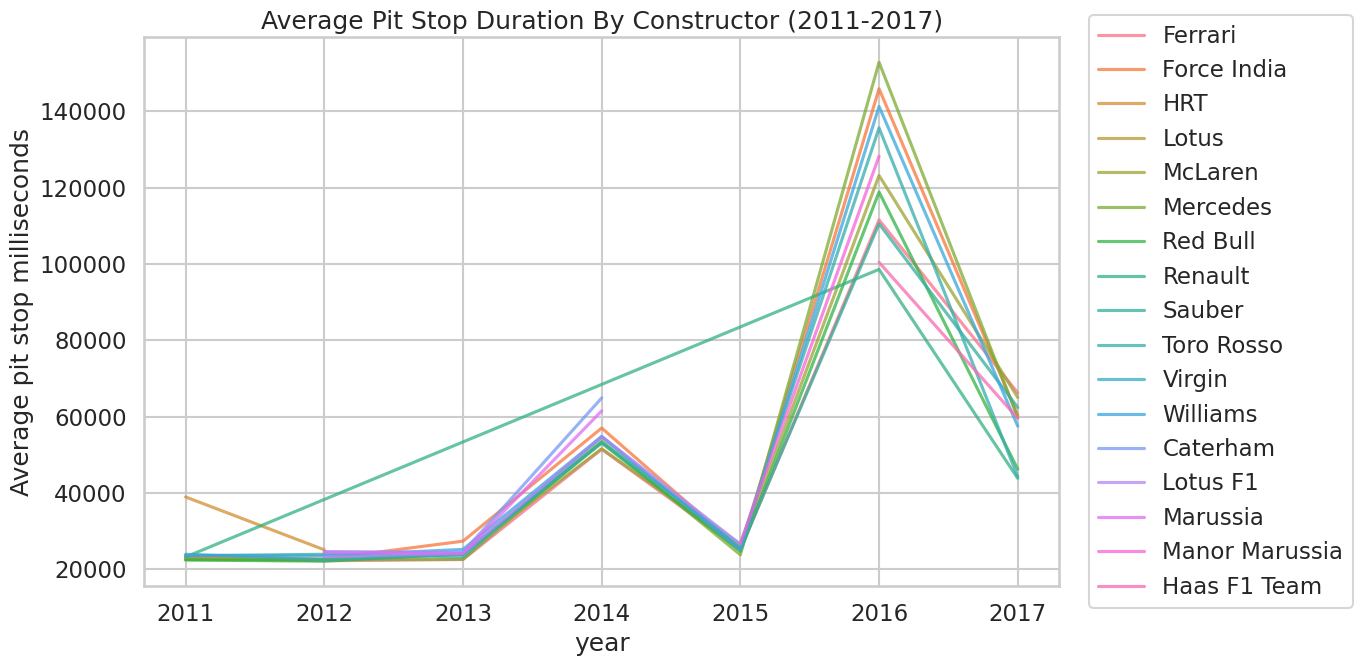

In [13]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(
                data=pit_stop_constructor_summary,
                x="year",
                y="avg_pit_ms",
                hue="constructor_name",
                estimator=None,
                alpha=0.75,
                ax=ax,
)
ax.set_title("Average Pit Stop Duration By Constructor (2011-2017)")
ax.set_ylabel("Average pit stop milliseconds")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


The chart reveals team-level operational differences across seasons.

            Result:

            - Some constructors are consistently efficient.
            - Others show higher volatility, which often indicates operational instability rather than pure race pace.

            This is why pit-stop analysis belongs in the report even if the predictive model excludes pit-stop variables:

            - Pit stops are strong *post-race* explanatory variables.
            - They are not valid *pre-race* predictors if the goal is a deployable forecasting pipeline.


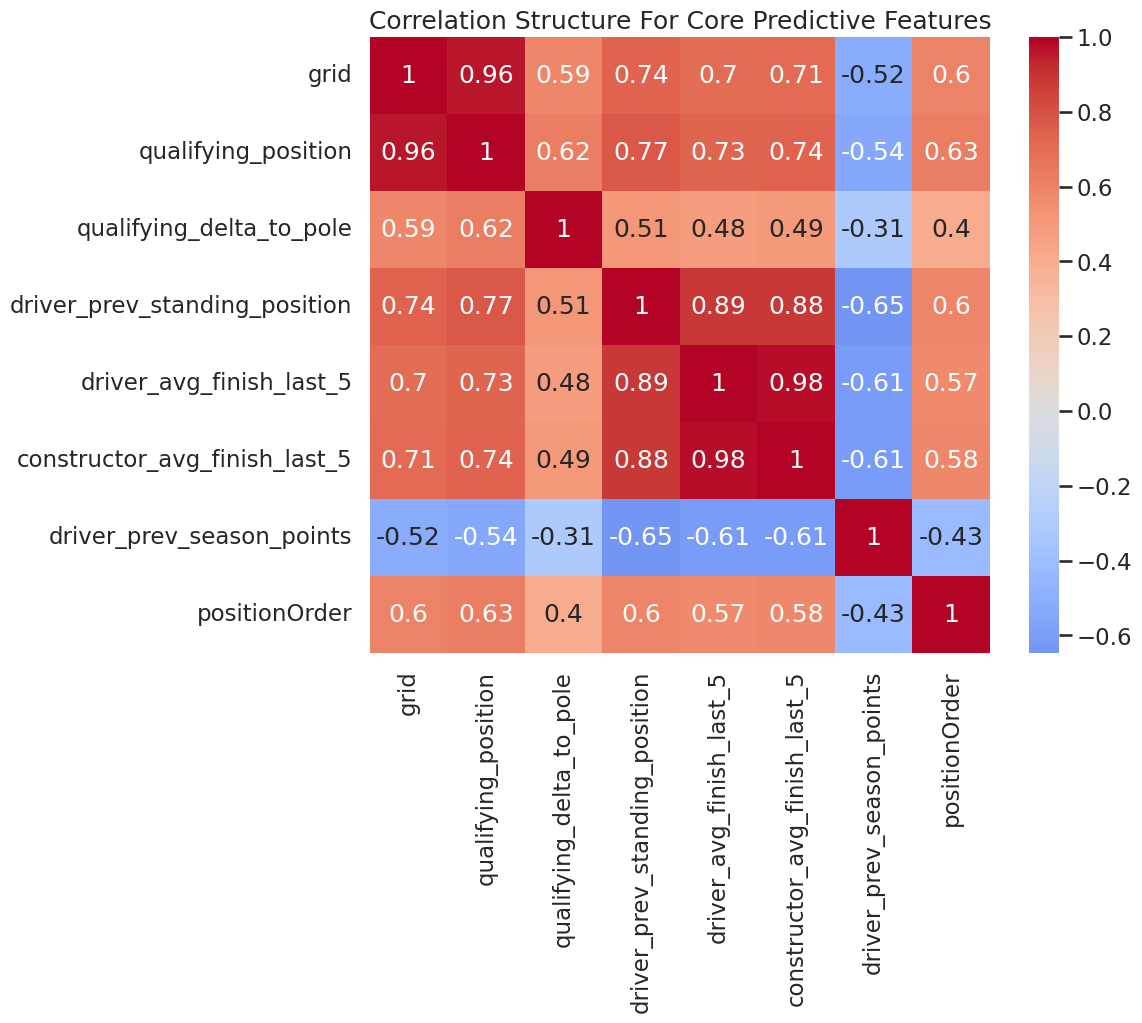

In [14]:
feature_corr = modeling_dataset[[
                "grid",
                "qualifying_position",
                "qualifying_delta_to_pole",
                "driver_prev_standing_position",
                "driver_avg_finish_last_5",
                "constructor_avg_finish_last_5",
                "driver_prev_season_points",
                "positionOrder",
            ]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(feature_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Structure For Core Predictive Features")
plt.show()


This correlation map provides a fast diagnostic before modeling.
Result:
- Grid and qualifying variables should correlate strongly with finish order.
- Historical driver and constructor form should add medium-strength signal.

  Important caveat:
- Correlation is not the same as causation.
- A model can still benefit from variables with low pairwise correlation because ensembles learn nonlinear interactions.


## Machine Learning Mathematics

---

### 1. Ridge Regression

We predict the target variable (e.g., finish position) with:

$$
\hat{y} = X\beta
$$

**Ridge Regression** minimizes the residual sum of squares plus an $L_2$ penalty:

$$
\min_{\beta} \; \|y - X\beta\|_2^2 + \lambda \|\beta\|_2^2
$$

The penalty term shrinks coefficients and stabilizes estimates when features are highly correlated, helping to prevent overfitting.

---

### 2. Logistic Regression

For classification tasks (e.g., podium classification):

$$
P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = X\beta
$$

The model is optimized by minimizing **Log-Loss** (Cross-Entropy):

$$
-\sum_{i=1}^{n} \left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]
$$

---

### 3. Random Forest

A forest reduces variance by averaging the predictions of many individual decision trees:

$$
\hat{f}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)
$$

Where each tree $T_b$ is trained on a **bootstrap sample** and random feature subsets. This "bagging" process captures nonlinear relationships while remaining robust to noise.

---

### 4. Evaluation Metrics

| Metric | Formula |
| :--- | :--- |
| **MAE** | $\frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$ |
| **RMSE** | $\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$ |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ |
| **F1 Score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ |

* **ROC-AUC**: Measures the ranking quality and the model's ability to distinguish between classes across all possible classification thresholds.

In [16]:
bundle = train_and_select_models(modeling_dataset, MODEL_DIR)
print("Chosen models:", bundle.chosen_models)
pd.DataFrame(bundle.validation_metrics).T


Chosen models: {'regression': 'ridge_finish_position', 'classification': 'forest_podium'}


,mae,rmse,accuracy,f1,roc_auc
ridge_finish_position,3.530563,4.730546,NaN,NaN,NaN
forest_finish_position,3.594899,4.718956,NaN,NaN,NaN
logistic_podium,NaN,NaN,0.853392,0.612717,0.947345
forest_podium,NaN,NaN,0.910284,0.713287,0.954395


This action trains candidate models on historical seasons and selects them using a validation season.

Result:
- We compare simple linear structure against nonlinear ensembles.
- The selected model is not chosen on the final test season, which keeps the holdout honest.

Pipeline logic:
- Numeric features are imputed and scaled.
- Categorical features are imputed and one-hot encoded.
- The estimator is chained after preprocessing in one object.

That means the saved artifact already contains the full transformation graph needed for later deployment.


In [18]:
with open(MODEL_DIR / "model_metrics.json", "r", encoding="utf-8") as handle:
                metrics = json.load(handle)

print(json.dumps(metrics["test_metrics"], indent=2))


{
  "ridge_finish_position": {
    "mae": 3.5541352012192022,
    "rmse": 4.605492466558113
  },
  "forest_podium": {
    "accuracy": 0.8869346733668342,
    "f1": 0.6808510638297872,
    "roc_auc": 0.9434418145956606
  }
}


This is the true out-of-sample performance on the final holdout season.
How to read it:
- Lower `mae` and `rmse` are better for finish-position prediction.
- Higher `roc_auc` and `f1` are better for podium classification.

 If the random forest wins, the interpretation is that finishing order depends on nonlinear interactions between pace, starting position, and recent form.


In [20]:
feature_importance = pd.read_csv(MODEL_DIR / "podium_feature_importance.csv").head(15)
feature_importance

,feature,importance
0,numeric__qualifying_position,0.120540
1,numeric__grid,0.098948
2,numeric__qualifying_delta_to_pole,0.069264
3,numeric__driver_prev_standing_position,0.057436
4,numeric__driver_podium_rate_last_10,0.055571
5,numeric__constructor_avg_grid_last_5,0.050190
6,numeric__constructor_avg_points_last_5,0.048501
7,numeric__constructor_podium_rate_last_10,0.044727
8,numeric__driver_avg_grid_last_5,0.044084
9,numeric__driver_avg_points_last_5,0.041701


Feature importance helps us explain the model beyond headline accuracy.

Result:
- Qualifying and grid-related features should rank highly.
- Historical driver and constructor form should also appear near the top.

This matters operationally because it tells us whether the model is learning race-weekend strength, season momentum, or both.


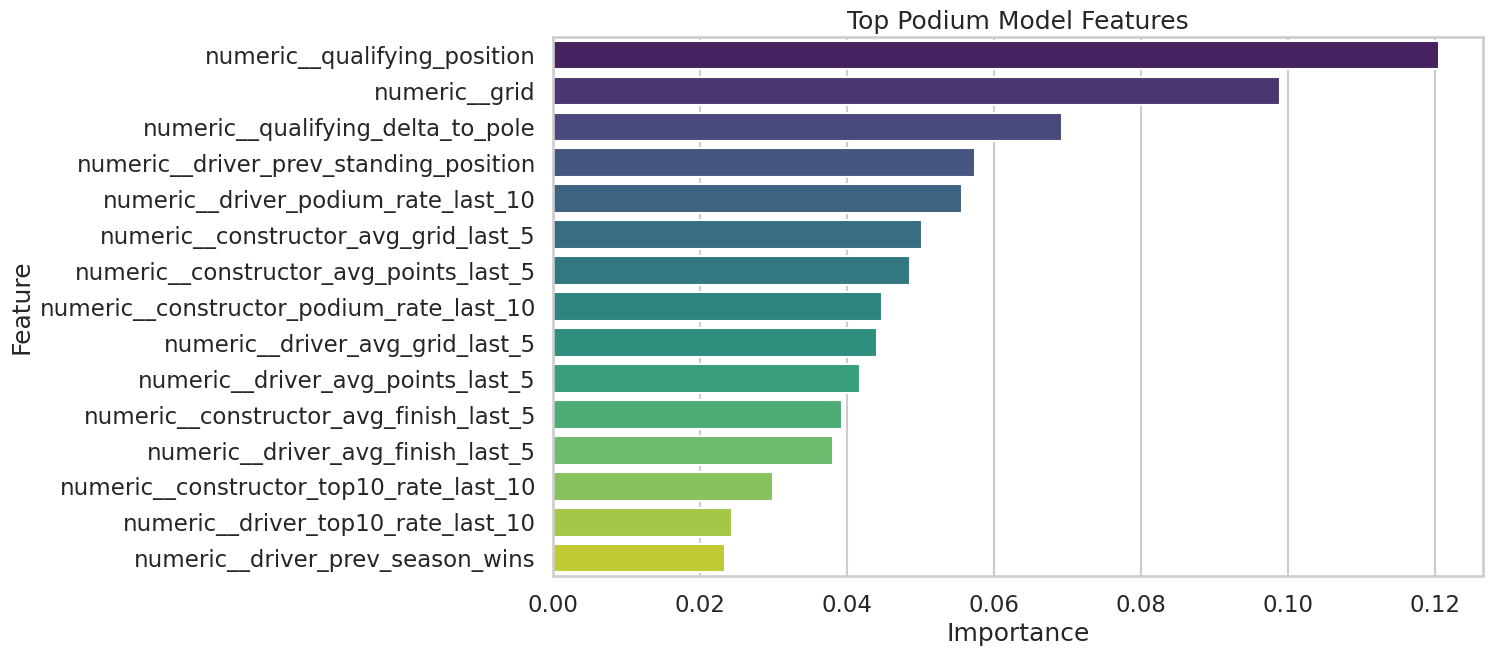

In [21]:
plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance, x="importance", y="feature", palette="viridis")
plt.title("Top Podium Model Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


The bar chart makes the learned drivers of podium probability easier to interpret.

Result:
- The strongest variables show where race outcome signal lives.
- This is useful for deciding what to preserve when building a production feature pipeline later.


In [1]:
# 1. Load your models
regression_pipeline = joblib.load(MODEL_DIR / "finish_position_pipeline.joblib")
classification_pipeline = joblib.load(MODEL_DIR / "podium_pipeline.joblib")

# 2. Get the ACTUAL features the model expects
# This uses the metadata stored inside the fitted pipeline
EXPECTED_FEATURES = list(regression_pipeline.feature_names_in_)

# 3. Prepare your data
future_ready_frame = modeling_dataset.dropna(subset=["qualifying_position"]).query("year == 2017").copy()

# Ensure we grab the metadata columns + the EXACT features the model needs
metadata_cols = ["year", "raceId", "driver_name", "constructor_name", "grid", "qualifying_position", "positionOrder", "podium"]
sample_predictions = future_ready_frame[metadata_cols + EXPECTED_FEATURES].head(10).copy()

# 4. Predict using the EXPECTED_FEATURES order
sample_predictions["predicted_finish_position"] = regression_pipeline.predict(
    sample_predictions[EXPECTED_FEATURES]
)
sample_predictions["predicted_podium_probability"] = classification_pipeline.predict_proba(
    sample_predictions[EXPECTED_FEATURES]
)[:, 1]

# 5. Display results
display_cols = ["driver_name", "constructor_name", "grid", "qualifying_position", "positionOrder", 
                "predicted_finish_position", "podium", "predicted_podium_probability"]
print(sample_predictions[display_cols])

NameError: name 'joblib' is not defined

This final action proves the saved objects behave like deployable pipelines.

Result:

- Raw feature columns go in.
- Predictions come out without manual preprocessing.

That is exactly the structure needed for a later batch job, web service, or scheduled inference pipeline.


## Final Interpretation

Recommended professional analysis for this dataset:

* **Operational Performance Analysis**: Use pit-stop tables to evaluate team efficiency and mechanical consistency.
* **Pre-Race Outcome Prediction**: Utilize results, qualifying, standings, and race metadata.
* **Methodological Separation**: Keep these two tracks separate to ensure that explanation (why things happened) and prediction (what will happen) remain analytically clean.

---

### Best Next Steps

1.  **Enhance Feature Engineering**: Add lap-time derived pace features to create stronger proxies for current driver form.
2.  **Model Optimization**: Implement a hyperparameter search specifically tuned on the validation season.
3.  **Deployment**: Wrap the saved pipelines in a scoring script to enable future-race simulations and real-time predictions.